# Select any class and view frames


In [1]:
from src.configs import get_class_list

# locals
from src.stats import AVAIL_SETS, AVAIL_SPLITS, get_all_sets
from src.utils import plt_display_grid
from src.visualise2 import FrameFetcher, set_thesis_style


## Setup:

Set variables for dataset loading

In [2]:
# all_classes = get_class_list()
set_thesis_style()
verbosity = 2
frame_size = 256
target_length = 16
split_idx = 3 #change for different split
set_idx = 1 #change for different set
split_options: list[AVAIL_SPLITS] = ["asl100", "asl300", "asl1000", "asl2000", 'asl100_bottom', 'asl100_worst']
set_options: list[AVAIL_SETS] = ['train', 'test', 'val']
split_name: AVAIL_SPLITS = split_options[split_idx]
set_name: AVAIL_SETS = set_options[set_idx]
class_name = "drink" #change for different class
all_classes = get_class_list()
cls_index = all_classes.index(class_name) 
all_sets = get_all_sets(split_name)
frame_fetcher = FrameFetcher(
    cls_idx=cls_index,
    all_sets=all_sets,
    set_name=set_name,
    split_name=split_name,
    frame_size=frame_size,
    target_length=target_length
)
# print_v = printv(verbosity)

### View frames

See example frames in a composite grid

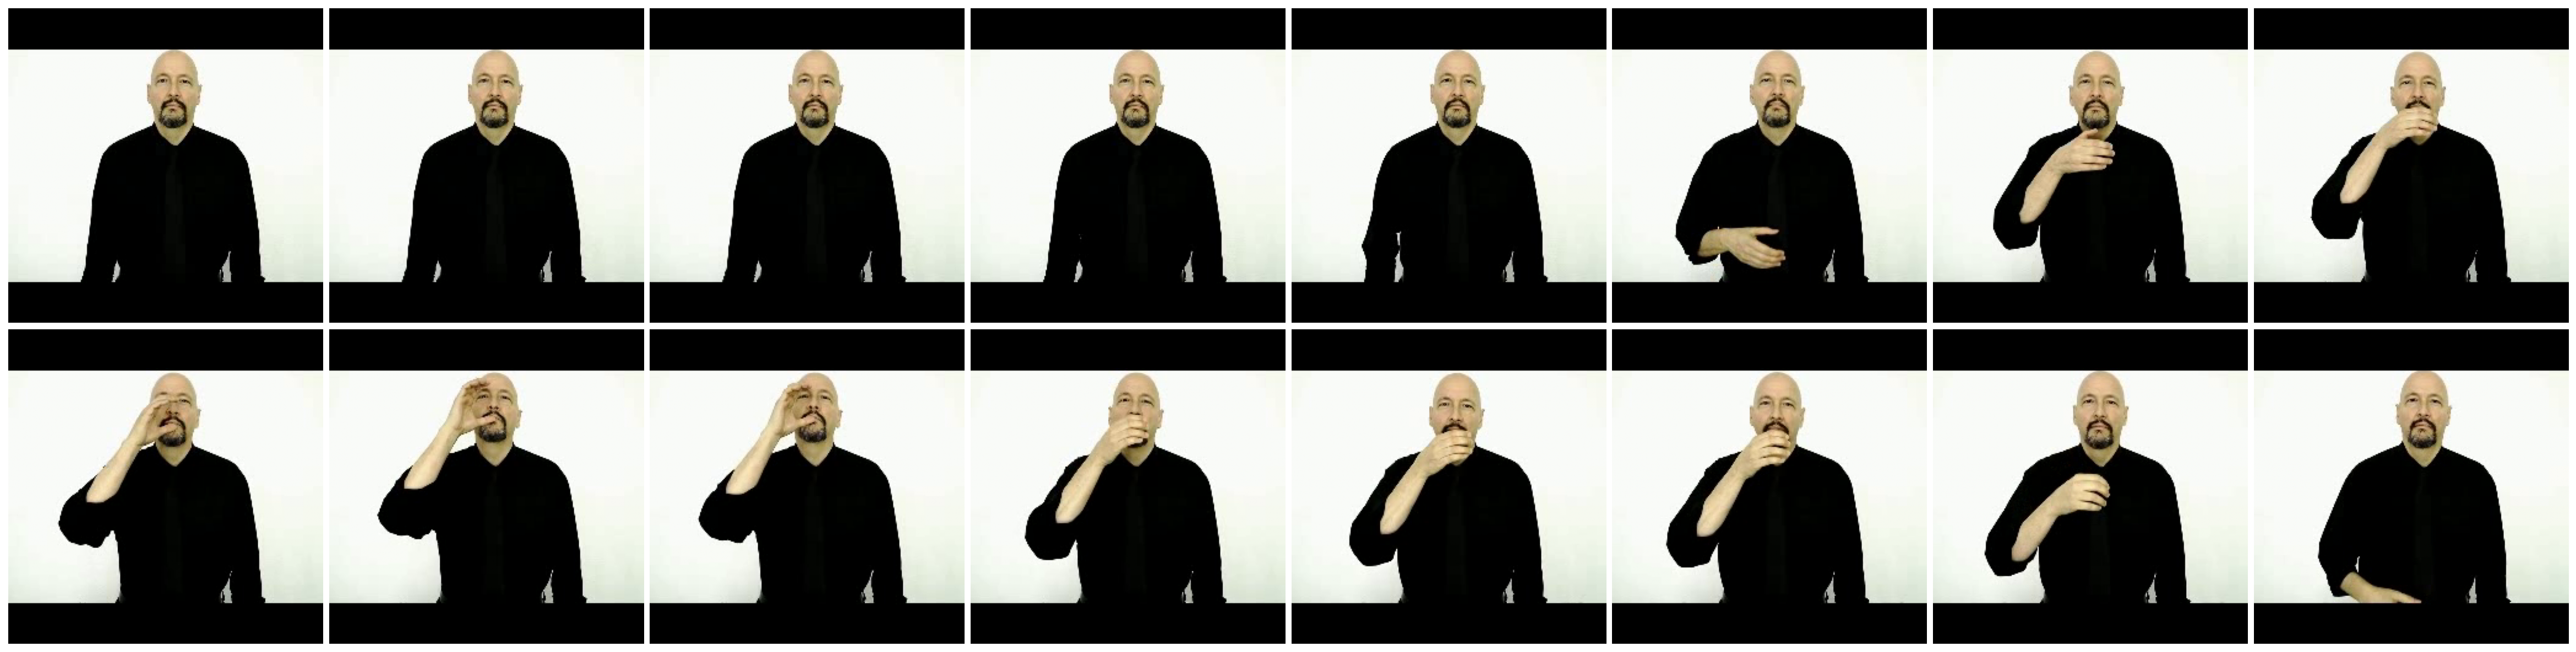

Class 1 is drink
Sample: 1 / 4


In [3]:
frames = frame_fetcher()
plt_display_grid(frames, num=target_length)
print(f"Class {cls_index} is {all_classes[cls_index]}")
print(f'Sample: {frame_fetcher.cur_idx} / {frame_fetcher.len}')

Or alternatively individual frames

In [4]:
# plt_display(frames, num=target_length, size=(2.5, 2.5), dpi=200, interpolation='lanczos', output_dir=f'./outputs/{class_name}_{frame_fetcher.cur_idx}/', file_suffix='.pdf')

# Find a class by video ID:

In [4]:
from collections.abc import Callable

from src.preprocess import Instance
from src.video_dataset import load_split_set


def _find_instance(predicate: Callable[[Instance], bool], set_name: AVAIL_SETS) -> Instance:
    split_set = load_split_set(split='asl2000', set_name=set_name, policy='strict')
    for obj in split_set:
        if isinstance(obj, Instance) and predicate(obj):
            return obj
    raise ValueError(f"No matching instance found in set {set_name!r}")

def _find_class_direct(video_id: str, set_name: AVAIL_SETS) -> int:
    return _find_instance(lambda inst: inst.video_id == video_id, set_name).label_num

    
print(_find_class_direct('07092', 'test'))  

def find_class(video_id: str, set_name: AVAIL_SETS  | None = None) -> int:
    set_names: list[AVAIL_SETS] = [set_name] if set_name is not None else ['test', 'val', 'train']
    for name in set_names:
        try:
            return _find_class_direct(video_id, name)
        except ValueError:
            pass
    raise ValueError(f"video_id {video_id!r} not found in any sets: {set_names}")
    
print(find_class('69241'))  

0
0
